##### Parallel Workflow

In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display, Image

In [25]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_percentage: float
    boundary_per_balls: int
    summary: str


In [35]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    total_runs = state['runs']
    balls_played = state['balls']

    strike_rate = (total_runs / balls_played) * 100
    
    return {'strike_rate': strike_rate} # partial update -> only updated state ko send krrhe otherwise (error when working with parallel(conflict))

In [36]:
def calculate_boundary_percent(state: BatsmanState) -> BatsmanState:
    total_runs_scored = state['runs']
    runs_from_boundaries = state['fours'] * 4 + state['sixes'] * 6
    
    bp = (runs_from_boundaries / total_runs_scored) * 100

    return {'boundary_percentage': bp}


In [37]:
def calculate_boundary_per_balls(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['sixes']
    balls_played = state['balls']

    bpb = balls_played / total_boundaries

    return {'boundary_per_balls': bpb}


In [38]:
def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
        Strike Rate - {state['strike_rate']} \n
        Balls per Boundary - {state['boundary_per_balls']}
        Boundary percentage - {state['boundary_percentage']}

    """
    
    return {'summary': summary}


In [39]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('calculate_boundary_per_balls', calculate_boundary_per_balls)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_boundary_percent')
graph.add_edge(START, 'calculate_boundary_per_balls')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')
graph.add_edge('calculate_boundary_per_balls', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

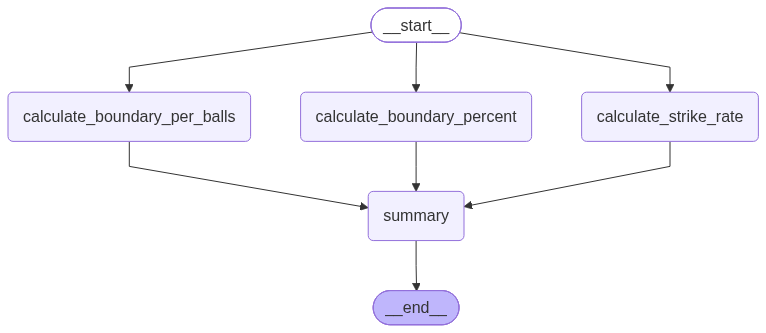

In [33]:
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

In [40]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'boundary_percentage': 48.0,
 'boundary_per_balls': 5.0,
 'summary': '\n        Strike Rate - 200.0 \n\n        Balls per Boundary - 5.0\n        Boundary percentage - 48.0\n\n    '}